In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    r"E:\da projects\Retail Profit Leak Detective\data\raw data\Superstore_dataset.csv",
    encoding="cp1252")

In [2]:
df.shape

(9994, 21)

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
Row ID           9994 non-null int64
Order ID         9994 non-null object
Order Date       9994 non-null object
Ship Date        9994 non-null object
Ship Mode        9994 non-null object
Customer ID      9994 non-null object
Customer Name    9994 non-null object
Segment          9994 non-null object
Country          9994 non-null object
City             9994 non-null object
State            9994 non-null object
Postal Code      9994 non-null int64
Region           9994 non-null object
Product ID       9994 non-null object
Category         9994 non-null object
Sub-Category     9994 non-null object
Product Name     9994 non-null object
Sales            9994 non-null float64
Quantity         9994 non-null int64
Discount         9994 non-null float64
Profit           9994 non-null float64
dtypes: float64(3), int64(3), object(15)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.isnull().sum().sum()

0

In [8]:
df.duplicated().sum()

0

In [9]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [10]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
df[["Sales","Quantity","Discount","Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [12]:
df[["Sales","Quantity","Discount","Profit"]].min()

Sales          0.444
Quantity       1.000
Discount       0.000
Profit     -6599.978
dtype: float64

In [13]:
df[["Sales","Quantity","Discount","Profit"]].max()

Sales       22638.480
Quantity       14.000
Discount        0.800
Profit       8399.976
dtype: float64

In [14]:
df["Category"].value_counts()

Office Supplies    6026
Furniture          2121
Technology         1847
Name: Category, dtype: int64

In [15]:
df["Sub-Category"].value_counts()

Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: Sub-Category, dtype: int64

In [16]:
df["Region"].value_counts()

West       3203
East       2848
Central    2323
South      1620
Name: Region, dtype: int64

In [17]:
df[ df["Profit"]<0].shape

(1871, 21)

In [18]:
(df["Profit"]<0).mean()* 100

18.721232739643785

In [19]:
df.nsmallest(10, "Profit")[["Order ID", "Product Name", "Category", "Sub-Category", "Sales", "Quantity", "Discount", "Profit"]]

,Order ID,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,4499.985,5,0.7,-6599.9780
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,4,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,2549.985,5,0.7,-3399.9800
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,1799.994,2,0.7,-2639.9912
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,4297.644,13,0.4,-1862.3124
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,6,0.5,-1811.0784


In [20]:
df.groupby("Discount")["Profit"].agg(["count", "mean", "sum"]).round(2)

,count,mean,sum
Discount,,,
0.00,4798,66.90,320987.60
0.10,94,96.06,9029.18
0.15,52,27.29,1418.99
0.20,3657,24.70,90337.31
0.30,227,-45.68,-10369.28
0.32,27,-88.56,-2391.14
0.40,206,-111.93,-23057.05
0.45,11,-226.65,-2493.11
0.50,66,-310.70,-20506.43


In [21]:
df.groupby("Discount").apply(
    lambda x: (x["Profit"] < 0).mean() * 100
).round(2)

Discount
0.00      0.00
0.10      4.26
0.15     32.69
0.20     13.73
0.30     91.63
0.32    100.00
0.40     87.38
0.45    100.00
0.50    100.00
0.60    100.00
0.70    100.00
0.80    100.00
dtype: float64

In [22]:
df.groupby("Category").apply(
    lambda x: (x["Profit"] < 0).mean() * 100
).round(2)

Category
Furniture          33.66
Office Supplies    14.70
Technology         14.67
dtype: float64

In [23]:
df.groupby("Sub-Category").agg(
    Orders=("Order ID", "nunique"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Profit=("Profit", "mean"),
    Avg_Discount=("Discount", "mean")
).sort_values("Profit").round(2)

,Orders,Sales,Profit,Avg_Profit,Avg_Discount
Sub-Category,,,,,
Tables,307,206965.53,-17725.48,-55.57,0.26
Bookcases,224,114880.00,-3472.56,-15.23,0.21
Supplies,187,46673.54,-1189.10,-6.26,0.08
Fasteners,215,3024.28,949.52,4.38,0.08
Machines,112,189238.63,3384.76,29.43,0.31
Labels,346,12486.31,5546.25,15.24,0.07
Art,731,27118.79,6527.79,8.20,0.07
Envelopes,249,16476.40,6964.18,27.42,0.08
Furnishings,877,91705.16,13059.14,13.65,0.14


In [24]:
df.groupby("Sub-Category").apply(
    lambda x: (x["Profit"] < 0).mean() * 100
).sort_values(ascending=False).round(2)

Sub-Category
Tables         63.64
Bookcases      47.81
Binders        40.25
Machines       38.26
Chairs         38.09
Storage        19.03
Furnishings    17.45
Supplies       17.37
Phones         15.30
Appliances     14.38
Accessories    11.74
Fasteners       5.53
Copiers         0.00
Envelopes       0.00
Labels          0.00
Art             0.00
Paper           0.00
dtype: float64

In [25]:
loss_df = df[df["Profit"] < 0].copy()

In [26]:
loss_df.shape

(1871, 21)

In [27]:
loss_df.groupby("Sub-Category").agg(
    Loss_Transactions=("Profit", "count"),
    Lost_Sales=("Sales", "sum"),
    Total_Loss=("Profit", "sum"),
    Avg_Loss=("Profit", "mean"),
    Avg_Discount=("Discount", "mean")
).sort_values("Total_Loss").round(2)

,Loss_Transactions,Lost_Sales,Total_Loss,Avg_Loss,Avg_Discount
Sub-Category,,,,,
Binders,613,36140.61,-38510.50,-62.82,0.74
Tables,203,104978.55,-32412.15,-159.67,0.37
Machines,44,72456.25,-30118.67,-684.52,0.58
Bookcases,109,48072.74,-12152.21,-111.49,0.35
Chairs,235,91988.46,-9880.84,-42.05,0.26
Appliances,67,3382.53,-8629.64,-128.80,0.80
Phones,136,35797.84,-7530.62,-55.37,0.34
Furnishings,167,12845.84,-6490.91,-38.87,0.53
Storage,161,37869.07,-6426.30,-39.91,0.20


In [28]:
loss_df.groupby(["Sub-Category", "Discount"]).agg(
    Transactions=("Profit", "count"),
    Total_Loss=("Profit", "sum"),
    Avg_Loss=("Profit", "mean")
).sort_values("Total_Loss").head(15).round(2)

,,Transactions,Total_Loss,Avg_Loss
Sub-Category,Discount,,,
Binders,0.8,233,-21909.40,-94.03
Machines,0.7,23,-19579.32,-851.27
Binders,0.7,380,-16601.10,-43.69
Tables,0.4,75,-16187.40,-215.83
Appliances,0.8,67,-8629.64,-128.80
Tables,0.5,36,-8615.39,-239.32
Machines,0.5,12,-7635.23,-636.27
Chairs,0.3,148,-6737.12,-45.52
Phones,0.4,97,-6715.78,-69.23


In [29]:
loss_df.groupby("Product Name").agg(
    Loss_Transactions=("Profit", "count"),
    Total_Loss=("Profit", "sum"),
    Avg_Loss=("Profit", "mean"),
    Avg_Discount=("Discount", "mean"),
    Lost_Sales=("Sales", "sum")
).sort_values("Total_Loss").head(15).round(2)

,Loss_Transactions,Total_Loss,Avg_Loss,Avg_Discount,Lost_Sales
Product Name,,,,,
Cubify CubeX 3D Printer Double Head Print,2,-9239.97,-4619.98,0.70,6299.98
GBC DocuBind P400 Electric Binding System,3,-6859.39,-2286.46,0.77,4899.56
Lexmark MX611dhe Monochrome Laser Printer,3,-5269.97,-1756.66,0.50,13769.92
GBC Ibimaster 500 Manual ProClick Binding System,6,-5098.57,-849.76,0.72,6696.62
GBC DocuBind TL300 Electric Binding System,4,-4162.03,-1040.51,0.73,4395.25
Cubify CubeX 3D Printer Triple Head Print,1,-3839.99,-3839.99,0.50,7999.98
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,2,-3431.67,-1715.84,0.80,2287.78
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,4,-3107.53,-776.88,0.35,8264.70
Ibico EPK-21 Electric Binding System,1,-2929.48,-2929.48,0.80,1889.99


In [30]:
df_clean=df.copy()

In [31]:
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    errors="coerce"
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"],
    errors="coerce"
)

In [32]:
df_clean[["Order Date", "Ship Date"]].isnull().sum()

Order Date    0
Ship Date     0
dtype: int64

In [33]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [34]:
df_clean["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [35]:
df_clean["Region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [36]:
df_clean["Segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [37]:
df_clean["Ship Mode"].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [38]:
text_columns = df_clean.select_dtypes(include="object").columns

text_columns

Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country', 'City', 'State', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name'],
      dtype='object')

In [39]:
for col in text_columns:
    spaces = (
        df_clean[col].astype(str).str.strip()
        .ne(df_clean[col].astype(str))
        .sum()
    )
    print(col, spaces)

Order ID 0
Ship Mode 0
Customer ID 0
Customer Name 0
Segment 0
Country 0
City 0
State 0
Region 0
Product ID 0
Category 0
Sub-Category 0
Product Name 16


In [40]:
print("Negative Sales:", (df_clean["Sales"] < 0).sum())
print("Zero/Negative Quantity:", (df_clean["Quantity"] <= 0).sum())
print(
    "Invalid Discount:",
    ((df_clean["Discount"] < 0) | (df_clean["Discount"] > 1)).sum()
)

Negative Sales: 0
Zero/Negative Quantity: 0
Invalid Discount: 0


In [41]:
df_clean.loc[
    df_clean["Product Name"].astype(str).str.strip()
    != df_clean["Product Name"].astype(str),
    ["Product ID", "Product Name"]
]

,Product ID,Product Name
808,TEC-AC-10004901,Kensington SlimBlade Notebook Wireless Mouse w...
889,TEC-AC-10000927,Anker Ultrathin Bluetooth Wireless Keyboard Al...
1019,OFF-ST-10001526,Iceberg Mobile Mega Data/Printer Cart
2169,TEC-AC-10000927,Anker Ultrathin Bluetooth Wireless Keyboard Al...
2641,TEC-AC-10000927,Anker Ultrathin Bluetooth Wireless Keyboard Al...
2759,OFF-ST-10001526,Iceberg Mobile Mega Data/Printer Cart
2839,OFF-ST-10001526,Iceberg Mobile Mega Data/Printer Cart
3590,OFF-ST-10001526,Iceberg Mobile Mega Data/Printer Cart
3893,TEC-AC-10004901,Kensington SlimBlade Notebook Wireless Mouse w...
4900,OFF-ST-10001526,Iceberg Mobile Mega Data/Printer Cart


In [42]:
for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

In [43]:
for col in text_columns:
    spaces = (
        df_clean[col].astype(str).str.strip()
        .ne(df_clean[col].astype(str))
        .sum()
    )
    print(col, spaces)

Order ID 0
Ship Mode 0
Customer ID 0
Customer Name 0
Segment 0
Country 0
City 0
State 0
Region 0
Product ID 0
Category 0
Sub-Category 0
Product Name 0


In [44]:
df_clean.duplicated().sum()

0

In [45]:
df_clean.isnull().sum().sum()

0

In [46]:
df_clean.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [47]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Missing cells:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Negative Sales:", (df_clean["Sales"] < 0).sum())
print("Invalid Quantity:", (df_clean["Quantity"] <= 0).sum())
print(
    "Invalid Discount:",
    ((df_clean["Discount"] < 0) | (df_clean["Discount"] > 1)).sum()
)

Rows: 9994
Columns: 21
Missing cells: 0
Duplicate rows: 0
Negative Sales: 0
Invalid Quantity: 0
Invalid Discount: 0


In [48]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793


In [49]:
category_analysis = df_clean.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

category_analysis

,Sales,Profit,Quantity
Category,,,
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906
Technology,836154.0330,145454.9481,6939


In [50]:
category_analysis["Profit Margin %"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Furniture,741999.80,18451.27,8028,2.49
Office Supplies,719047.03,122490.80,22906,17.04
Technology,836154.03,145454.95,6939,17.40


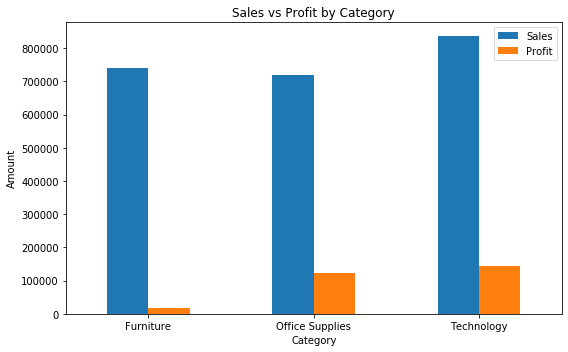

In [51]:
import matplotlib.pyplot as plt

category_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
subcategory_analysis = df_clean.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

subcategory_analysis["Profit Margin %"] = (
    subcategory_analysis["Profit"] / subcategory_analysis["Sales"]
) * 100

subcategory_analysis = subcategory_analysis.sort_values(
    "Profit", ascending=True
)

subcategory_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Sub-Category,,,,
Tables,206965.53,-17725.48,1241,-8.56
Bookcases,114880.00,-3472.56,868,-3.02
Supplies,46673.54,-1189.10,647,-2.55
Fasteners,3024.28,949.52,914,31.40
Machines,189238.63,3384.76,440,1.79
Labels,12486.31,5546.25,1400,44.42
Art,27118.79,6527.79,3000,24.07
Envelopes,16476.40,6964.18,906,42.27
Furnishings,91705.16,13059.14,3563,14.24


In [53]:
discount_analysis = df_clean.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

discount_analysis["Profit Margin %"] = (
    discount_analysis["Profit"] / discount_analysis["Sales"]
) * 100

discount_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,1087908.47,320987.60,18267,29.51
0.10,54369.35,9029.18,373,16.61
0.15,27558.52,1418.99,198,5.15
0.20,764594.37,90337.31,13660,11.82
0.30,103226.65,-10369.28,849,-10.05
0.32,14493.46,-2391.14,105,-16.50
0.40,116417.78,-23057.05,786,-19.81
0.45,5484.97,-2493.11,45,-45.45
0.50,58918.54,-20506.43,241,-34.80


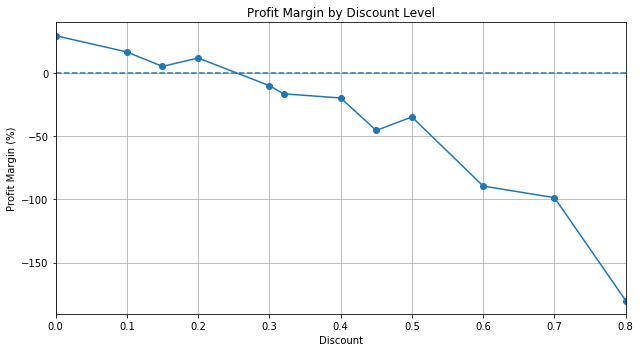

In [54]:
discount_analysis["Profit Margin %"].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Profit Margin by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, linestyle="--")
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
subcategory_discount = df_clean.groupby(
    ["Sub-Category", "Discount"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

subcategory_discount["Profit Margin %"] = (
    subcategory_discount["Profit"] /
    subcategory_discount["Sales"]
) * 100

subcategory_discount.round(2)

Sales    Profit  Quantity  Profit Margin %
Sub-Category Discount                                                
Accessories  0.00      118370.31  35289.25      1835            29.81
             0.20       49010.01   6647.38      1141            13.56
Appliances   0.00       78066.19  23183.74      1021            29.70
             0.10        4324.15   1086.08        55            25.12
             0.20       21759.29   2497.83       418            11.48
             0.80        3382.53  -8629.64       235          -255.12
Art          0.00       18014.64   5380.60      1904            29.87
             0.20        9104.15   1147.19      1096            12.60
Binders      0.00       81829.48  39314.45      1291            48.04
             0.20       85442.64  29417.81      2227            34.43
             0.70       22559.39 -16601.10      1503           -73.59
             0.80       13581.22 -21909.40       953          -161.32
Bookcases    0.00       31935.98   6075.71       211            19.02
             0.15       27558.52   1418.99       198             5.15
             0.20       26841.50    130.50       167             0.49
             0.30        4282.70   -555.87        43           -12.98
             0.32       14493.46  -2391.14       105           -16.50
             0.50        7308.46  -4255.81        76           -58.23
             0.70        2459.38  -3894.94        68          -158.37
Chairs       0.00       91060.73  21933.10       540            24.09
             0.10       46634.25   7111.01       313            15.25
             0.20      120748.62   4283.17       889             3.55
             0.30       70005.50  -6737.12       614            -9.62
Copiers      0.00       76449.18  35556.13        82            46.51
             0.20       56159.05  17878.71       119            31.84
             0.40       16919.80   2182.98        33            12.90
Envelopes    0.00       10606.45   4976.98       548            46.92
             0.20        5869.95   1987.19       358            33.85
Fasteners    0.00        1822.84    652.21       504            35.78
             0.20        1201.44    297.31       410            24.75
Furnishings  0.00       61449.80  16847.97      2163            27.42
             0.20       23610.66   2155.83       899             9.13
             0.60        6644.70  -5944.66       501           -89.46
Labels       0.00        9239.56   4422.10       945            47.86
             0.20        3246.75   1124.16       455            34.62
Machines     0.00       71034.00  27137.82       138            38.20
             0.10        3410.96    832.08         5            24.39
             0.20       37954.57   4970.20       117            13.10
             0.30        3756.30    326.04        12             8.68
             0.40       19546.22  -2666.84        47           -13.64
             0.50       37935.07  -7635.23        32           -20.13
             0.70       15601.51 -19579.32        89          -125.50
Paper        0.00       53157.87  25329.47      3229            47.65
             0.20       25321.34   8724.10      1949            34.45
Phones       0.00      123879.71  34365.21      1102            27.74
             0.20      171789.99  16536.31      1773             9.63
             0.40       34337.35  -6385.79       414           -18.60
Storage      0.00      157853.76  25528.17      2044            16.17
             0.20       65989.85  -4249.35      1114            -6.44
Supplies     0.00       31559.21   1718.39       400             5.44
             0.20       15114.33  -2907.49       247           -19.24
Tables       0.00       71578.76  13276.30       310            18.55
             0.20       45430.23   -303.56       281            -0.67
             0.30       25182.15  -3402.33       180           -13.51
             0.40       45614.41 -16187.40       292           -35.49
             0.45        5484.97  -24

In [56]:
loss_df = df_clean[df_clean["Profit"] < 0].copy()

print("Loss-making transactions:", len(loss_df))

Loss-making transactions: 1871


In [57]:
loss_by_subcategory = loss_df.groupby("Sub-Category").agg(
    Loss_Transactions=("Profit", "size"),
    Total_Loss=("Profit", "sum"),
    Average_Loss=("Profit", "mean")
)

loss_by_subcategory = loss_by_subcategory.sort_values(
    "Total_Loss"
)

loss_by_subcategory.round(2)

,Loss_Transactions,Total_Loss,Average_Loss
Sub-Category,,,
Binders,613,-38510.50,-62.82
Tables,203,-32412.15,-159.67
Machines,44,-30118.67,-684.52
Bookcases,109,-12152.21,-111.49
Chairs,235,-9880.84,-42.05
Appliances,67,-8629.64,-128.80
Phones,136,-7530.62,-55.37
Furnishings,167,-6490.91,-38.87
Storage,161,-6426.30,-39.91


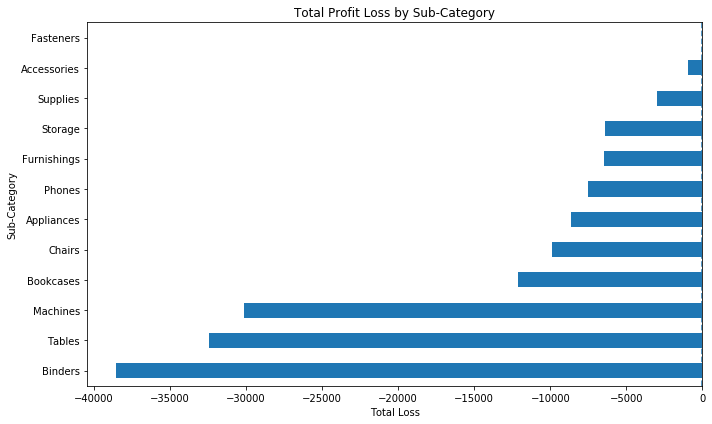

In [58]:
import matplotlib.pyplot as plt

loss_by_subcategory["Total_Loss"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Profit Loss by Sub-Category")
plt.xlabel("Total Loss")
plt.ylabel("Sub-Category")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

In [59]:
loss_discount = loss_df.groupby(
    ["Sub-Category", "Discount"]
).agg(
    Loss_Transactions=("Profit", "size"),
    Total_Loss=("Profit", "sum"),
    Average_Loss=("Profit", "mean")
)

loss_discount = loss_discount.sort_values(
    "Total_Loss"
)

loss_discount.round(2)

,,Loss_Transactions,Total_Loss,Average_Loss
Sub-Category,Discount,,,
Binders,0.80,233,-21909.40,-94.03
Machines,0.70,23,-19579.32,-851.27
Binders,0.70,380,-16601.10,-43.69
Tables,0.40,75,-16187.40,-215.83
Appliances,0.80,67,-8629.64,-128.80
Tables,0.50,36,-8615.39,-239.32
Machines,0.50,12,-7635.23,-636.27
Chairs,0.30,148,-6737.12,-45.52
Phones,0.40,97,-6715.78,-69.23


In [60]:
high_discount_loss = loss_df[loss_df["Discount"] >= 0.30]

print("High-discount loss transactions:", len(high_discount_loss))
print(
    "High-discount total loss:",
    round(high_discount_loss["Profit"].sum(), 2)
)

print(
    "Percentage of loss transactions:",
    round(len(high_discount_loss) / len(loss_df) * 100, 2),
    "%"
)

print(
    "Percentage of total losses:",
    round(
        abs(high_discount_loss["Profit"].sum()) /
        abs(loss_df["Profit"].sum()) * 100,
        2
    ),
    "%"
)

High-discount loss transactions: 1348
High-discount total loss: -138515.24
Percentage of loss transactions: 72.05 %
Percentage of total losses: 88.72 %


In [61]:
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M")

monthly_analysis = df_clean.groupby("Year-Month").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

monthly_analysis["Profit Margin %"] = (
    monthly_analysis["Profit"] /
    monthly_analysis["Sales"]
) * 100

monthly_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Year-Month,,,,
2014-01,14236.89,2450.19,284,17.21
2014-02,4519.89,862.31,159,19.08
2014-03,55691.01,498.73,585,0.90
2014-04,28295.34,3488.84,536,12.33
2014-05,23648.29,2738.71,466,11.58
2014-06,34595.13,4976.52,521,14.39
2014-07,33946.39,-841.48,550,-2.48
2014-08,27909.47,5318.10,609,19.05
2014-09,81777.35,8328.10,1000,10.18


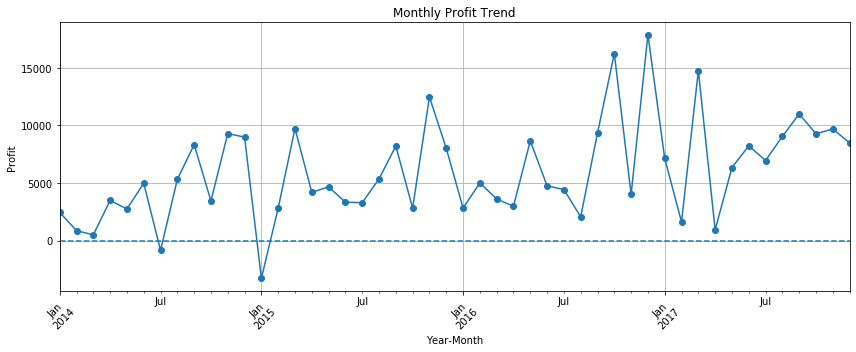

In [62]:
monthly_analysis["Profit"].plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
yearly_analysis = df_clean.groupby(
    df_clean["Order Date"].dt.year
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

yearly_analysis["Profit Margin %"] = (
    yearly_analysis["Profit"] /
    yearly_analysis["Sales"]
) * 100

yearly_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Order Date,,,,
2014,484247.50,49543.97,7581,10.23
2015,470532.51,61618.60,7979,13.10
2016,609205.60,81795.17,9837,13.43
2017,733215.26,93439.27,12476,12.74


In [64]:
region_analysis = df_clean.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

region_analysis["Profit Margin %"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis = region_analysis.sort_values(
    "Profit Margin %",
    ascending=True
)

region_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Region,,,,
Central,501239.89,39706.36,8780,7.92
South,391721.91,46749.43,6209,11.93
East,678781.24,91522.78,10618,13.48
West,725457.82,108418.45,12266,14.94


In [65]:
central_category = df_clean[
    df_clean["Region"] == "Central"
].groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

central_category["Profit Margin %"] = (
    central_category["Profit"] /
    central_category["Sales"]
) * 100

central_category.round(2)

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Furniture,163797.16,-2871.05,1827,-1.75
Office Supplies,167026.42,8879.98,5409,5.32
Technology,170416.31,33697.43,1544,19.77


In [66]:
central_furniture = df_clean[
    (df_clean["Region"] == "Central") &
    (df_clean["Category"] == "Furniture")
].groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

central_furniture["Profit Margin %"] = (
    central_furniture["Profit"] /
    central_furniture["Sales"]
) * 100

central_furniture = central_furniture.sort_values(
    "Profit Margin %",
    ascending=True
)

central_furniture.round(2)

,Sales,Profit,Quantity,Profit Margin %
Sub-Category,,,,
Furnishings,15254.37,-3906.22,758,-25.61
Tables,39154.97,-3559.65,262,-9.09
Bookcases,24157.18,-1997.90,192,-8.27
Chairs,85230.65,6592.72,615,7.74


In [67]:
central_furniture_discount = df_clean[
    (df_clean["Region"] == "Central") &
    (df_clean["Category"] == "Furniture")
].groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

central_furniture_discount["Profit Margin %"] = (
    central_furniture_discount["Profit"] /
    central_furniture_discount["Sales"]
) * 100

central_furniture_discount.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,74929.35,16641.38,613,22.21
0.30,61178.98,-6866.89,543,-11.22
0.32,14493.46,-2391.14,105,-16.50
0.50,6550.67,-4309.74,65,-65.79
0.60,6644.70,-5944.66,501,-89.46


In [68]:
central_furniture_sub_discount = df_clean[
    (df_clean["Region"] == "Central") &
    (df_clean["Category"] == "Furniture")
].groupby(
    ["Sub-Category", "Discount"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

central_furniture_sub_discount["Profit Margin %"] = (
    central_furniture_sub_discount["Profit"] /
    central_furniture_sub_discount["Sales"]
) * 100

central_furniture_sub_discount.round(2)

Sales    Profit  Quantity  Profit Margin %
Sub-Category Discount                                               
Bookcases    0.00       5381.02    949.11        44            17.64
             0.30       4282.70   -555.87        43           -12.98
             0.32      14493.46  -2391.14       105           -16.50
Chairs       0.00      44095.02  10687.07       233            24.24
             0.30      41135.63  -4094.34       382            -9.95
Furnishings  0.00       8609.67   2038.44       257            23.68
             0.60       6644.70  -5944.66       501           -89.46
Tables       0.00      16843.64   2966.77        79            17.61
             0.30      15760.66  -2216.68       118           -14.06
             0.50       6550.67  -4309.74        65           -65.79

In [69]:
subcategory_region = df_clean.groupby(
    ["Region", "Sub-Category"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

subcategory_region["Profit Margin %"] = (
    subcategory_region["Profit"] /
    subcategory_region["Sales"]
) * 100

subcategory_region = subcategory_region.sort_values(
    "Profit Margin %",
    ascending=True
)

subcategory_region.round(2)

Sales    Profit  Quantity  Profit Margin %
Region  Sub-Category                                               
East    Tables        39139.81 -11025.38       271           -28.17
Central Furnishings   15254.37  -3906.22       758           -25.61
        Appliances    23582.03  -2638.62       470           -11.19
East    Supplies      10760.12  -1155.14       195           -10.74
South   Tables        43916.19  -4623.06       227           -10.53
...                        ...       ...       ...              ...
        Labels         2353.18   1040.77       216            44.23
East    Paper         20172.60   9015.37      1400            44.69
West    Labels         5078.73   2303.12       480            45.35
        Paper         26663.72  12119.24      1702            45.45
        Envelopes      4118.10   1908.76       227            46.35

[68 rows x 4 columns]

In [70]:
east_tables_discount = df_clean[
    (df_clean["Region"] == "East") &
    (df_clean["Sub-Category"] == "Tables")
].groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

east_tables_discount["Profit Margin %"] = (
    east_tables_discount["Profit"] /
    east_tables_discount["Sales"]
) * 100

east_tables_discount.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.3,9421.49,-1185.65,62,-12.58
0.4,29718.32,-9839.73,209,-33.11


In [71]:
customer_analysis = df_clean.groupby(
    ["Customer ID", "Customer Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"),
    Quantity=("Quantity", "sum")
)

customer_analysis["Profit Margin %"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"]
) * 100

customer_analysis = customer_analysis.sort_values(
    "Profit",
    ascending=True
)

customer_analysis.head(10).round(2)

,,Sales,Profit,Orders,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
CS-12505,Cindy Stewart,5690.05,-6626.39,6,40,-116.46
GT-14635,Grant Thornton,9351.21,-4108.66,3,26,-43.94
LF-17185,Luke Foster,3930.51,-3583.98,7,69,-91.18
SR-20425,Sharelle Roach,3233.48,-3333.91,5,34,-103.11
HG-14965,Henry Goldwyn,3247.64,-2797.96,12,68,-86.15
NC-18415,Nathan Cano,2218.99,-2204.81,6,38,-99.36
SB-20290,Sean Braxton,8057.89,-2082.75,7,84,-25.85
SM-20320,Sean Miller,25043.05,-1980.74,5,50,-7.91
CP-12340,Christine Phan,5888.28,-1850.30,8,59,-31.42


In [72]:
worst_customers = customer_analysis.head(10).reset_index()

worst_customer_ids = worst_customers["Customer ID"]

worst_customer_discount = df_clean[
    df_clean["Customer ID"].isin(worst_customer_ids)
].groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)

worst_customer_discount["Profit Margin %"] = (
    worst_customer_discount["Profit"] /
    worst_customer_discount["Sales"]
) * 100

worst_customer_discount.round(2)

,Sales,Profit,Orders,Profit Margin %
Discount,,,,
0.0,8217.02,1719.24,31,20.92
0.1,383.61,63.93,1,16.67
0.2,5613.54,753.05,27,13.41
0.3,1767.33,-254.98,4,-14.43
0.4,9971.30,-2245.81,5,-22.52
0.5,31459.76,-5667.49,2,-18.02
0.6,41.47,-24.45,2,-58.95
0.7,11898.70,-15624.25,8,-131.31
0.8,5631.19,-8984.71,6,-159.55


In [73]:
top_loss_transactions = df_clean[
    df_clean["Profit"] < 0
].sort_values(
    "Profit",
    ascending=True
).head(10)

top_loss_transactions[
    [
        "Order ID",
        "Customer Name",
        "Product Name",
        "Category",
        "Sub-Category",
        "Region",
        "Sales",
        "Discount",
        "Profit"
    ]
].round(2)

,Order ID,Customer Name,Product Name,Category,Sub-Category,Region,Sales,Discount,Profit
7772,CA-2016-108196,Cindy Stewart,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,East,4499.98,0.7,-6599.98
683,US-2017-168116,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,South,7999.98,0.5,-3839.99
9774,CA-2014-169019,Luke Foster,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,Central,2177.58,0.8,-3701.89
3011,CA-2017-134845,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,West,2549.98,0.7,-3399.98
4991,US-2017-122714,Henry Goldwyn,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,Central,1889.99,0.8,-2929.48
3151,CA-2015-147830,Natalie Fritzler,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,East,1799.99,0.7,-2639.99
5310,CA-2017-131254,Nathan Cano,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,Central,1525.19,0.8,-2287.78
9639,CA-2015-116638,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,South,4297.64,0.4,-1862.31
1199,CA-2016-130946,Zuschuss Carroll,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,Central,1088.79,0.8,-1850.95
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,South,22638.48,0.5,-1811.08
